In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from keras.datasets import cifar10
import tensorflow as tf
from sklearn.model_selection import train_test_split

Train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)


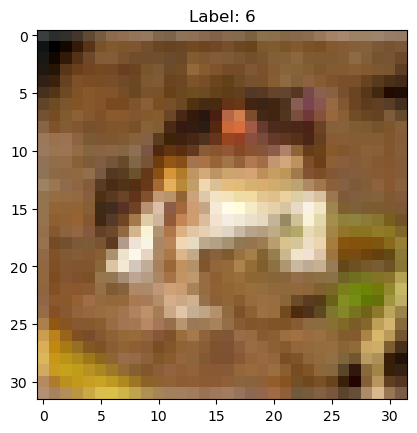

In [2]:
(trainImg, trainLabel), (testImg, testLabel) = cifar10.load_data()
print("Train shape:", trainImg.shape, "Test shape:", testImg.shape)

# show an example image
image = trainImg[0]
label = trainLabel[0][0]   # CIFAR-10 label shape is (1,)
plt.imshow(image)
plt.title(f"Label: {label}")
plt.show()

In [3]:
# combine training and test data
all_images = np.concatenate([trainImg, testImg], axis=0)
all_labels = np.concatenate([trainLabel, testLabel], axis=0).flatten()  

In [4]:
# cleaning method  - StandardScaler
def standardScaling(img):
    img = img.astype(np.float32)
    mean = np.mean(img)
    std = np.std(img)
    return (img - mean) / std

In [5]:
clean_images = np.array([standardScaling(img) for img in all_images])
clean_labels = all_labels.copy()

print("After cleaning:", clean_images.shape, clean_labels.shape)

After cleaning: (60000, 32, 32, 3) (60000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    clean_images, clean_labels, test_size=0.2, shuffle=True, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (48000, 32, 32, 3) Test: (12000, 32, 32, 3)


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),          # Random horizontal flip
    tf.keras.layers.RandomRotation(0.04),               # Random rotation
    tf.keras.layers.RandomZoom(0.05),                   # Random zoom
    tf.keras.layers.RandomTranslation(0.06, 0.066),       # Random translation
    tf.keras.layers.RandomContrast(0.08),               # Random contrast
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3732748].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.356446].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.265745].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2622527].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4477156].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3819942].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3699487].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2991847].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4127208].


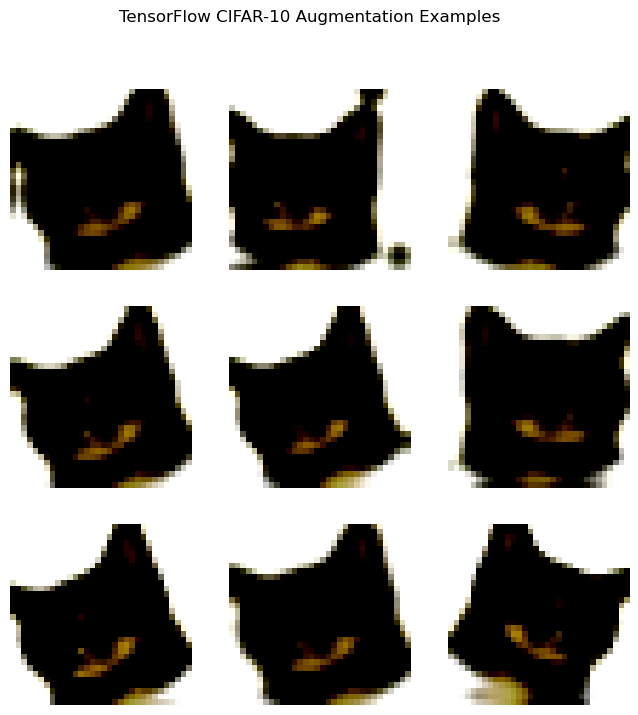

In [8]:
sample = X_train[0]

plt.figure(figsize=(8, 8))
for i in range(9):
    augmented = data_augmentation(tf.expand_dims(sample, 0))
    plt.subplot(3, 3, i+1)
    plt.imshow((augmented[0].numpy()))
    plt.axis("off")
plt.suptitle("TensorFlow CIFAR-10 Augmentation Examples")
plt.show()

In [9]:
model = tf.keras.Sequential([
    data_augmentation,                                  # Data augmentation layer
    tf.keras.layers.Rescaling(1./255),                  # Normalize

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/40


750/750 [==============================] - 88s 107ms/step - loss: 2.1494 - accuracy: 0.2219 - val_loss: 2.0755 - val_accuracy: 0.2412
Epoch 2/40
750/750 [==============================] - 80s 107ms/step - loss: 2.0122 - accuracy: 0.2740 - val_loss: 2.0428 - val_accuracy: 0.2612
Epoch 3/40
750/750 [==============================] - 80s 106ms/step - loss: 1.9571 - accuracy: 0.3004 - val_loss: 2.0365 - val_accuracy: 0.2833
Epoch 4/40
750/750 [==============================] - 80s 107ms/step - loss: 1.9021 - accuracy: 0.3232 - val_loss: 2.0788 - val_accuracy: 0.2944
Epoch 5/40
750/750 [==============================] - 80s 107ms/step - loss: 1.8598 - accuracy: 0.3416 - val_loss: 2.1124 - val_accuracy: 0.3162
Epoch 6/40
750/750 [==============================] - 81s 107ms/step - loss: 1.8235 - accuracy: 0.3546 - val_loss: 2.1959 - val_accuracy: 0.3175
Epoch 7/40
750/750 [==============================] - 80s 107ms/step - loss: 1.7955 - accuracy: 0.3645 - val_loss: 2.2726 - val_accuracy: 0.3

750/750 [==============================] - 80s 107ms/step - loss: 1.5255 - accuracy: 0.4591 - val_loss: 3.4028 - val_accuracy: 0.3292
Epoch 31/40
750/750 [==============================] - 80s 106ms/step - loss: 1.5202 - accuracy: 0.4602 - val_loss: 3.3979 - val_accuracy: 0.3313
Epoch 32/40
750/750 [==============================] - 80s 107ms/step - loss: 1.5119 - accuracy: 0.4632 - val_loss: 3.3843 - val_accuracy: 0.3343
Epoch 33/40
750/750 [==============================] - 80s 107ms/step - loss: 1.5111 - accuracy: 0.4658 - val_loss: 3.4405 - val_accuracy: 0.3334
Epoch 34/40
750/750 [==============================] - 80s 106ms/step - loss: 1.5054 - accuracy: 0.4673 - val_loss: 3.6591 - val_accuracy: 0.3223
Epoch 35/40
750/750 [==============================] - 80s 107ms/step - loss: 1.4985 - accuracy: 0.4679 - val_loss: 3.5561 - val_accuracy: 0.3315
Epoch 36/40
750/750 [==============================] - 80s 106ms/step - loss: 1.4950 - accuracy: 0.4700 - val_loss: 3.6260 - val_accurac

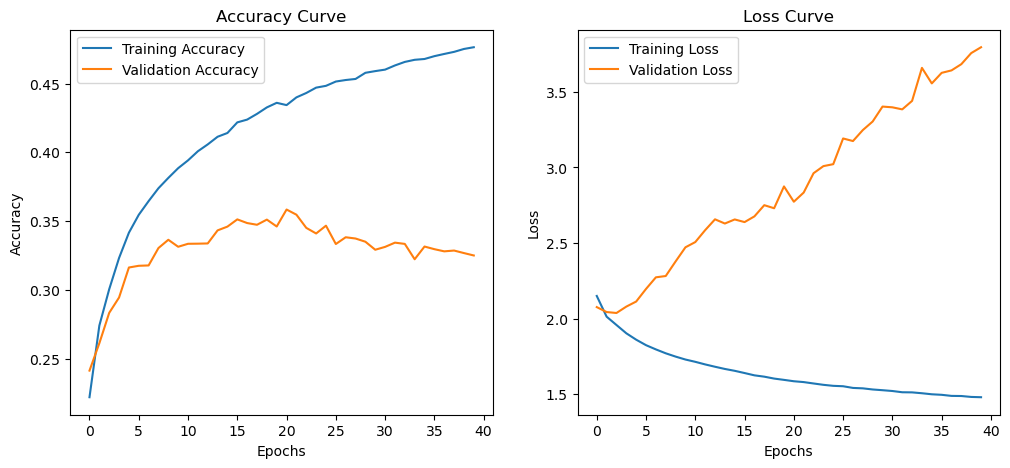

In [11]:
plt.figure(figsize=(12,5))

# Accuracy curve
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
# Baseline model (No augmentation)
model_no_aug = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(32,32,3)),  # Only normalize — no augmentation

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_no_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_no_aug = model_no_aug.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/40
750/750 [==============================] - 54s 71ms/step - loss: 2.0608 - accuracy: 0.2735 - val_loss: 1.9086 - val_accuracy: 0.3221
Epoch 2/40
750/750 [==============================] - 53s 71ms/step - loss: 1.8417 - accuracy: 0.3517 - val_loss: 1.7873 - val_accuracy: 0.3682
Epoch 3/40
750/750 [==============================] - 53s 71ms/step - loss: 1.7475 - accuracy: 0.3859 - val_loss: 1.7182 - val_accuracy: 0.3951
Epoch 4/40
750/750 [==============================] - 54s 71ms/step - loss: 1.6821 - accuracy: 0.4083 - val_loss: 1.6648 - val_accuracy: 0.4105
Epoch 5/40
750/750 [==============================] - 53s 71ms/step - loss: 1.6282 - accuracy: 0.4263 - val_loss: 1.6104 - val_accuracy: 0.4298
Epoch 6/40
750/750 [==============================] - 54s 72ms/step - loss: 1.5819 - accuracy: 0.4420 - val_loss: 1.5672 - val_accuracy: 0.4472
Epoch 7/40
750/750 [==============================] - 53s 71ms/step - loss: 1.5440 - accuracy: 0.4538 - val_loss: 1.5393 - val_accuracy:

Comparison of TensorFlow-augmented data and Original data

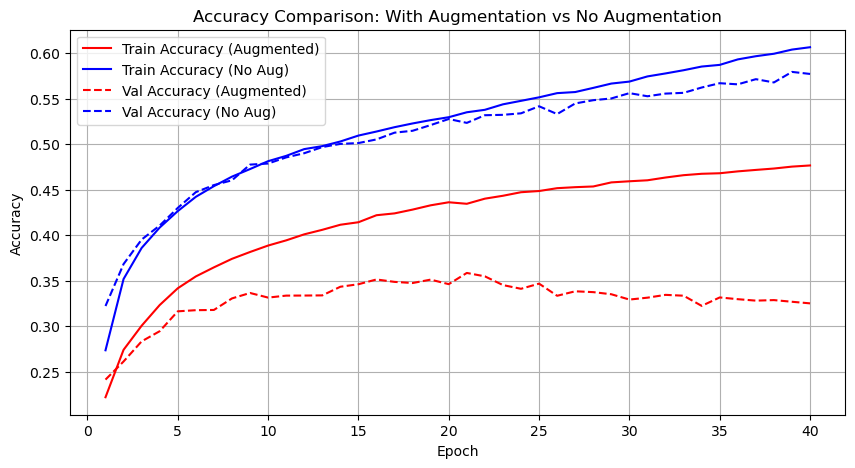

In [15]:
# Extract accuracy curves

acc_aug = history.history['accuracy']            # with augmentation
val_acc_aug = history.history['val_accuracy']

acc_no = history_no_aug.history['accuracy']      # without augmentation
val_acc_no = history_no_aug.history['val_accuracy']

epochs = range(1, len(acc_aug) + 1)   # assume both trained with same epoch count


# Plot comparison
plt.figure(figsize=(10,5))

# ---- Train Accuracy ----
plt.plot(epochs, acc_aug, 'r-', label='Train Accuracy (Augmented)')
plt.plot(epochs, acc_no, 'b-', label='Train Accuracy (No Aug)')

# ---- Validation Accuracy ----
plt.plot(epochs, val_acc_aug, 'r--', label='Val Accuracy (Augmented)')
plt.plot(epochs, val_acc_no, 'b--', label='Val Accuracy (No Aug)')

plt.title("Accuracy Comparison: With Augmentation vs No Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


The CIFAR-10 original dataset achieved ~0.58 validation accuracy, while TensorFlow-augmented data dropped to ~0.38, showing that augmentation harmed instead of improved performance. This may result from excessive transformation strength, loss of object features in low-resolution images, and a small CNN model unable to generalize effectively to heavily modified samples.